In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

2025-05-19 18:19:55.352906: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-19 18:19:55.396726: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-19 18:19:56.036202: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Load by file name
R2502_2503 = pd.read_pickle("R2502_2503.pkl")
R2503_2502 = pd.read_pickle("R2503_2502.pkl")
R2503_2504 = pd.read_pickle("R2503_2504.pkl")
R2504_2503 = pd.read_pickle("R2504_2503.pkl")
R2502_2504 = pd.read_pickle("R2502_2504.pkl")
R2504_2502 = pd.read_pickle("R2504_2502.pkl")

F2504 = pd.read_pickle("2504.pkl")

In [3]:
from pathlib import Path

# 1) Does a directory exist?
base = Path("/home/seismic/AxialFetch/MJ03F-B")
print(base, "→", base.exists(), "(dir)" if base.is_dir() else "(not a dir)")

# 2) Does one specific file exist?
f = base / "MJ03F-B2022DIFF-PRESS-15min.txt"
print(f, "→", f.exists())

# 3) Quick sweep over a pattern
for p in base.glob("MJ03F-B*DIFF-PRESS-15min.txt"):
    print("found:", p.name)

/home/seismic/AxialFetch/MJ03F-B → True (dir)
/home/seismic/AxialFetch/MJ03F-B/MJ03F-B2022DIFF-PRESS-15min.txt → True
found: MJ03F-B2023DIFF-PRESS-15min.txt
found: MJ03F-B2022DIFF-PRESS-15min.txt
found: MJ03F-B2021DIFF-PRESS-15min.txt
found: MJ03F-B2020DIFF-PRESS-15min.txt
found: MJ03F-B2019DIFF-PRESS-15min.txt
found: MJ03F-B2018DIFF-PRESS-15min.txt
found: MJ03F-B2017DIFF-PRESS-15min.txt
found: MJ03F-B2024DIFF-PRESS-15min.txt


Rows in df_pressure: 994


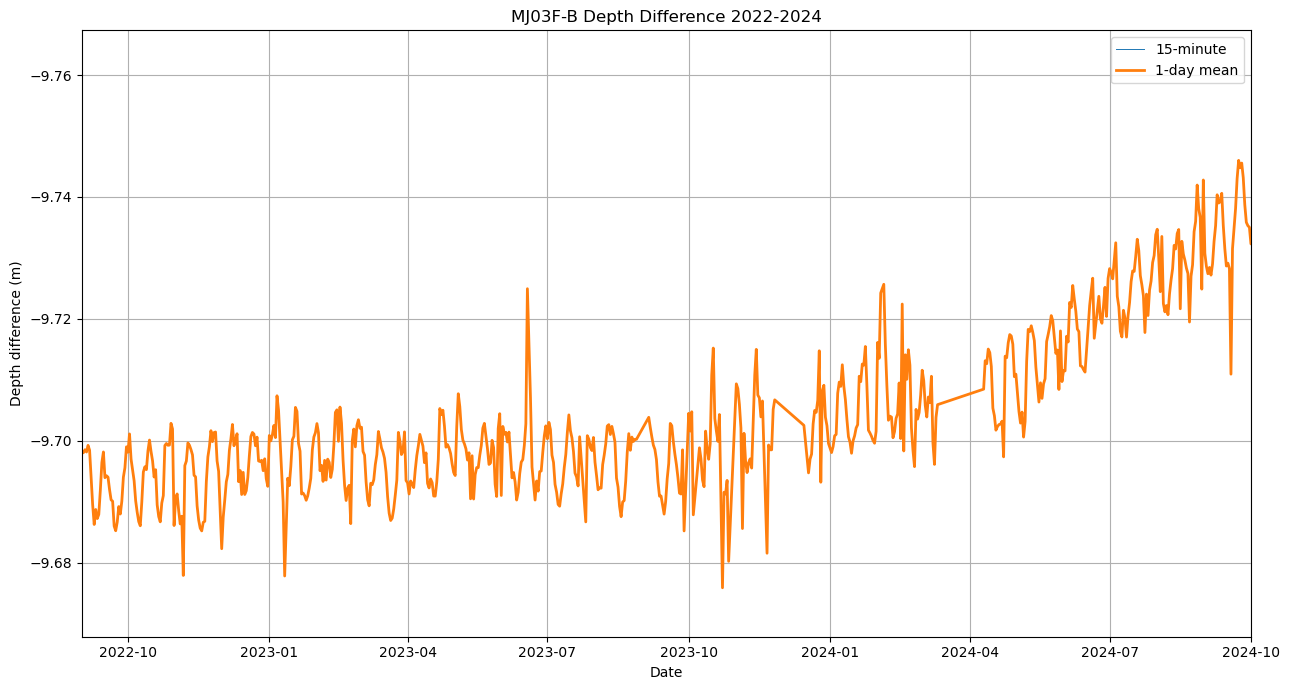

In [4]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-B")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-B DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-B{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-B Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
#plt.ylim(-14.55, -14.45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

del df_1day

Rows in df_pressure: 994


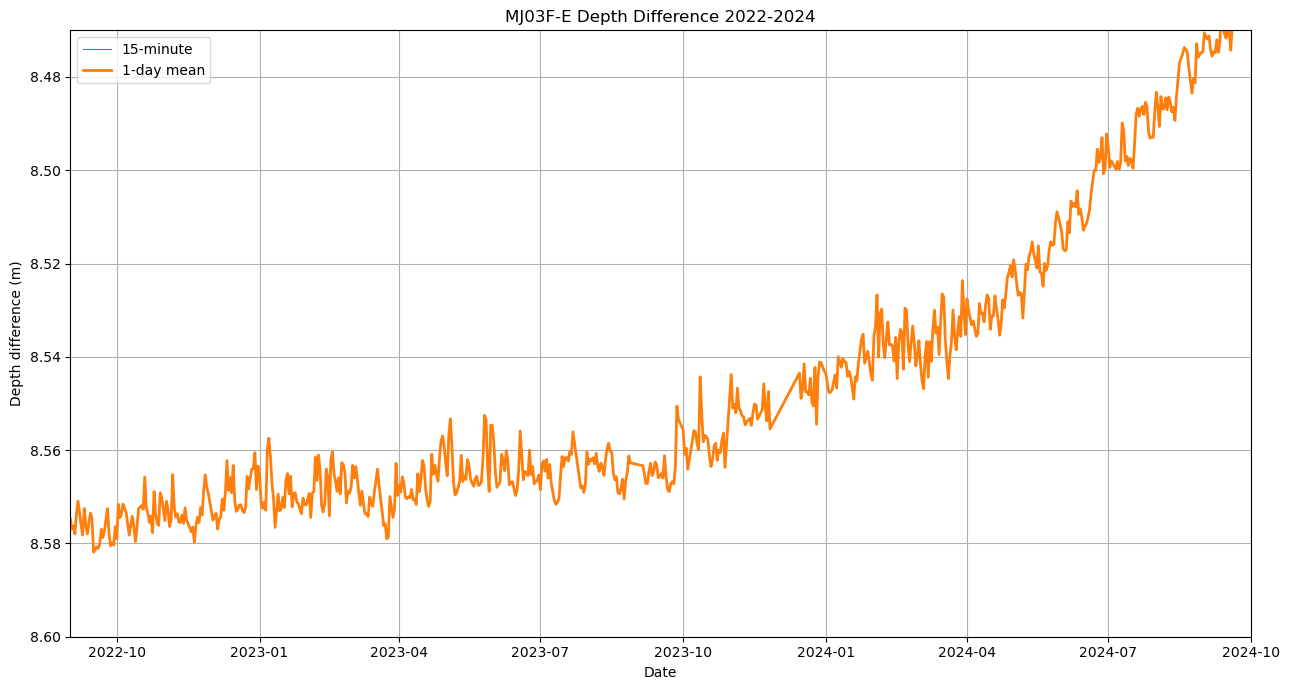

In [5]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-E")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-E DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-E{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure1 = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.47)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s

# ------------------------------------------------------------------
# 2) build the master grid from R2503_2504  (distance d1)
# ------------------------------------------------------------------
d1 = to_series(R2503_2502, "Record Time", "Moving Average")

df_var = d1.to_frame("d1")   # index = time, one column so far

# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------
# pressure difference p1 (comes from df_pressure)
p1 = (
    df_pressure.assign(time=pd.to_datetime(df_pressure["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

p2 = (
    df_pressure1.assign(time=pd.to_datetime(df_pressure1["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

# distance opposite direction d2
d2 = to_series(R2502_2503, "Record Time", "Moving Average")
d3 = to_series(R2502_2504, "Record Time", "Moving Average")
d4 = to_series(R2504_2502, "Record Time", "Moving Average")
d5 = to_series(R2503_2504, "Record Time", "Moving Average")
d6 = to_series(R2504_2503, "Record Time", "Moving Average")

# corrected pressure p2
p3 = to_series(F2504, "DateTime", "Corrected Pressure (kPa)")

In [7]:
# ------------------------------------------------------------------
# 4) interpolate everything onto the master grid
# ------------------------------------------------------------------
def onto_master(source, master_index):
    union = source.reindex(master_index.union(source.index))
    filled = union.interpolate("time")
    return filled.reindex(master_index)

df_var["p1"] = onto_master(p1, df_var.index)
df_var["d2"] = onto_master(d2, df_var.index)
df_var["p2"] = onto_master(p2, df_var.index)
df_var["p3"] = onto_master(p3, df_var.index)
df_var["d3"] = onto_master(d3, df_var.index)
df_var["d4"] = onto_master(d4, df_var.index)
df_var["d5"] = onto_master(d5, df_var.index)
df_var["d6"] = onto_master(d6, df_var.index)

# optional order
df_var = df_var[["p1", "p2", "p3", "d1", "d2", "d3", "d4", "d5", "d6"]]

# reset index so 'time' is a normal column
df_var = df_var.reset_index().rename(columns={"index": "time"})


In [8]:
import os
# -----------------------------------------------------------------------------
# 0) FORCE CPU PARALLELISM TO 48 CORES
# -----------------------------------------------------------------------------
os.environ["OMP_NUM_THREADS"]      = "48"
os.environ["MKL_NUM_THREADS"]      = "48"
os.environ["OPENBLAS_NUM_THREADS"] = "48"

import numpy as np
import pandas as pd
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks

# Tell TensorFlow to use 48 threads
tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)


In [9]:
import os
# -----------------------------------------------------------------------------
# FORCE CPU PARALLELISM TO 48 CORES
# -----------------------------------------------------------------------------
os.environ["OMP_NUM_THREADS"]      = "48"
os.environ["MKL_NUM_THREADS"]      = "48"
os.environ["OPENBLAS_NUM_THREADS"] = "48"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

# configure TensorFlow threading
tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)

# =============================================================================
# LINEAR-LAYER (TRAINABLE) + PHYSICS-INFORMED LOSS
# – TRAIN ON LAST 70% – EVALUATE FULL SERIES
# =============================================================================

# 0) LOAD & FILTER DATA
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var[df_var['Record Time'] >= pd.Timestamp(2022,9,7,tz='UTC')].reset_index(drop=True)

# map DataFrame
df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],
    'p2':   df_var['p2'],
    'p3':   df_var['p3'],
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_EC','r_CE','r_WC','r_CW']

# 1) FEATURE ENGINEERING for LS
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2 * np.pi / 365.25
df['sin_t'] = np.sin(ω * df['t_days'])
df['cos_t'] = np.cos(ω * df['t_days'])

# X_lin: [p3, p1, p2, sin_t, cos_t]
X_lin = np.column_stack([df['p3'], df['p1'], df['p2'], df['sin_t'], df['cos_t']])
# LS design matrix with intercept
X_ls  = np.column_stack([np.ones(len(X_lin)), X_lin])

# 2) LINEAR LEAST-SQUARES FIT for each baseline
Y = df[Y_cols].values
betas, *_ = np.linalg.lstsq(X_ls, Y, rcond=None)  # shape (6,6)

# LS predictions
R_lin_full = X_ls @ betas  # (N,6)

# 3) BUILD MODEL
# Inputs: 5-dim scaled X_lin
inputs = layers.Input(shape=(5,), name='inputs')
# Linear layer for LS trend
ls_layer = layers.Dense(6, activation='linear', name='ls_layer')
ls_out = ls_layer(inputs)
# initialize and make trainable
kernel = betas[1:,:]  # shape (5,6)
bias   = betas[0,:]  # shape (6,)
ls_layer.set_weights([kernel, bias])
ls_layer.trainable = True

# Residual MLP head
x = layers.Concatenate()([inputs, ls_out])
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
resid_out = layers.Dense(6, activation='linear', name='resid')(x)

# Hybrid output: LS + residual
hybrid_out = layers.Add(name='hybrid')([ls_out, resid_out])

# Multi-output model
model = Model(inputs, [hybrid_out, ls_out])

# 4) LOSS: data-fitting (hybrid) + physics-informed (LS)
λ_phys = 1.0
model.compile(
    optimizer='adam',
    loss={'hybrid':'mse', 'ls_layer':'mse'},
    loss_weights={'hybrid':1.0, 'ls_layer':λ_phys}
)

# 5) SCALE & SPLIT
scaler_X = StandardScaler().fit(X_lin)
Xs       = scaler_X.transform(X_lin).astype('float32')
Yh       = Y.astype('float32')
Yl       = R_lin_full.astype('float32')

# last 70% train
N = len(Xs)
start = int(0.30 * N)
X_train = Xs[start:]
Yh_train = Yh[start:]
Yl_train = Yl[start:]

# 6) TRAIN
es = callbacks.EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)
model.fit(
    X_train, {'hybrid': Yh_train, 'ls_layer': Yl_train},
    epochs=200, batch_size=len(X_train),
    callbacks=[es], verbose=1
)

# 7) PREDICT & EVALUATE FULL SERIES
Yh_pred, Yl_pred = model.predict(Xs)
print("LS-only metrics:")
for i,name in enumerate(Y_cols):
    r2_lin = r2_score(Y[:,i], R_lin_full[:,i])
    rmse_lin = mean_squared_error(Y[:,i], R_lin_full[:,i], squared=False)
    print(f"{name}: R²={r2_lin:.3f}, RMSE={rmse_lin:.3f} m")

print("\nHybrid PINN (trainable linear-layer) metrics:")
for i,name in enumerate(Y_cols):
    r2_h   = r2_score(Y[:,i], Yh_pred[:,i])
    rmse_h = mean_squared_error(Y[:,i], Yh_pred[:,i], squared=False)
    print(f"{name}: R²={r2_h:.3f}, RMSE={rmse_h:.3f} m")



Epoch 1/200


2025-05-19 18:20:56.623245: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


1/1 [==============================] - 1s 686ms/step - loss: 3997063424.0000 - hybrid_loss: 3895980800.0000 - ls_layer_loss: 101082816.0000
Epoch 2/200
1/1 [==============================] - 0s 6ms/step - loss: 2946056448.0000 - hybrid_loss: 2844973568.0000 - ls_layer_loss: 101082800.0000
Epoch 3/200
1/1 [==============================] - 0s 6ms/step - loss: 2085537664.0000 - hybrid_loss: 1984454912.0000 - ls_layer_loss: 101082776.0000
Epoch 4/200
1/1 [==============================] - 0s 6ms/step - loss: 1406826880.0000 - hybrid_loss: 1305744128.0000 - ls_layer_loss: 101082744.0000
Epoch 5/200
1/1 [==============================] - 0s 6ms/step - loss: 903006592.0000 - hybrid_loss: 801923840.0000 - ls_layer_loss: 101082744.0000
Epoch 6/200
1/1 [==============================] - 0s 6ms/step - loss: 550787392.0000 - hybrid_loss: 449704672.0000 - ls_layer_loss: 101082720.0000
Epoch 7/200
1/1 [==============================] - 0s 6ms/step - loss: 325943168.0000 - hybrid_loss: 224860480.000

1/1 [==============================] - 0s 7ms/step - loss: 102846480.0000 - hybrid_loss: 1764427.5000 - ls_layer_loss: 101082056.0000
Epoch 57/200
1/1 [==============================] - 0s 6ms/step - loss: 102804616.0000 - hybrid_loss: 1722574.1250 - ls_layer_loss: 101082040.0000
Epoch 58/200
1/1 [==============================] - 0s 5ms/step - loss: 102902184.0000 - hybrid_loss: 1820140.3750 - ls_layer_loss: 101082040.0000
Epoch 59/200
1/1 [==============================] - 0s 5ms/step - loss: 103077760.0000 - hybrid_loss: 1995735.6250 - ls_layer_loss: 101082024.0000
Epoch 60/200
1/1 [==============================] - 0s 5ms/step - loss: 103264320.0000 - hybrid_loss: 2182323.5000 - ls_layer_loss: 101082000.0000
Epoch 61/200
1/1 [==============================] - 0s 5ms/step - loss: 103401576.0000 - hybrid_loss: 2319578.2500 - ls_layer_loss: 101082000.0000
Epoch 62/200
1/1 [==============================] - 0s 5ms/step - loss: 103445408.0000 - hybrid_loss: 2363428.0000 - ls_layer_loss:

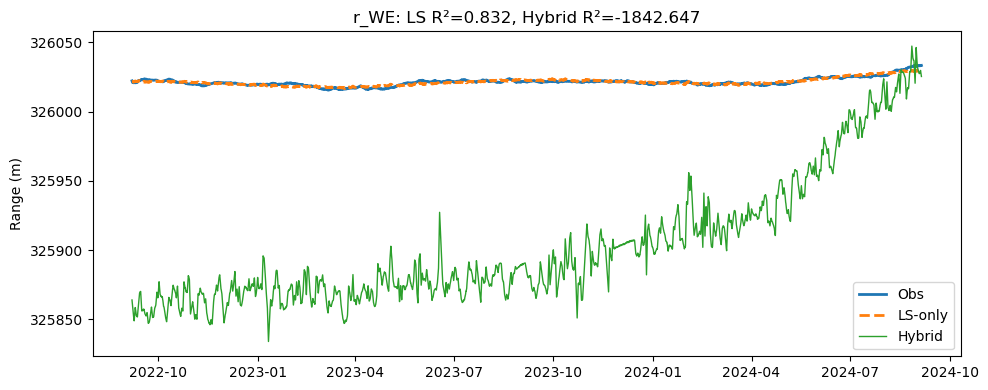

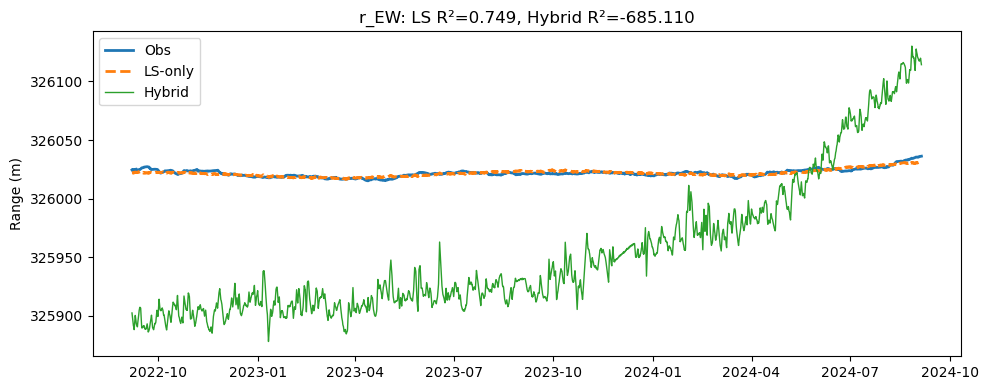

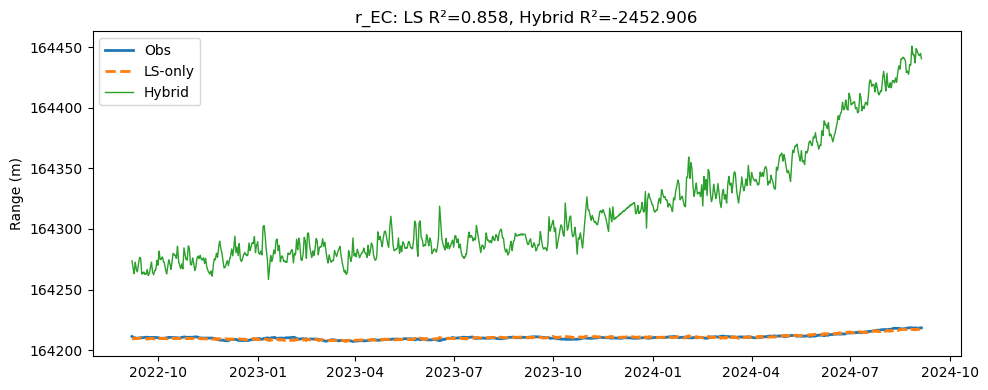

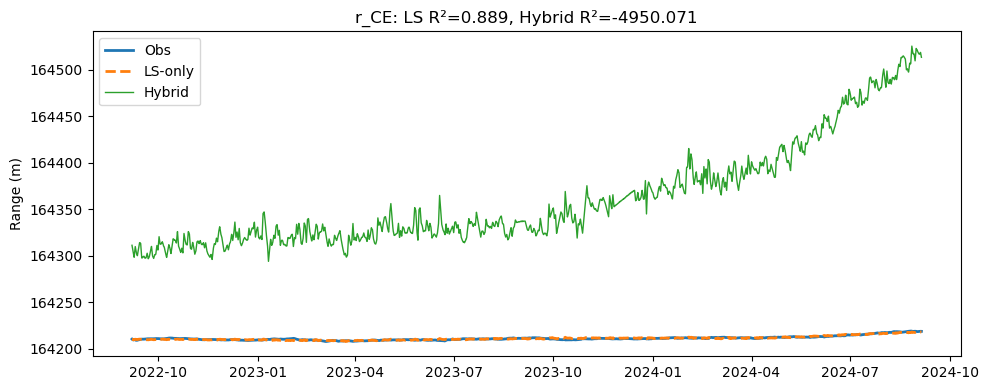

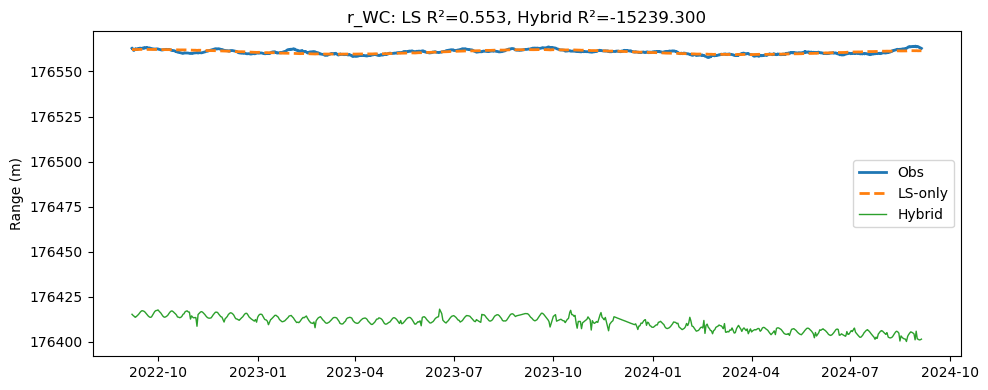

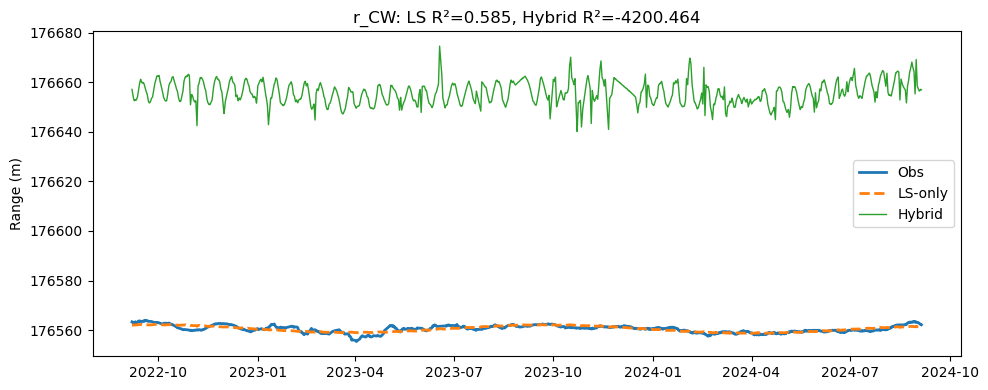

In [10]:
# 8) PLOT
for i,name in enumerate(Y_cols):
    fig, ax = plt.subplots(figsize=(10,4), tight_layout=True)
    ax.plot(df['time'], Y[:,i], label='Obs', lw=2)
    ax.plot(df['time'], R_lin_full[:,i], label='LS-only', ls='--', lw=2)
    ax.plot(df['time'], Yh_pred[:,i], label='Hybrid', lw=1)
    ax.set_title(f"{name}: LS R²={r2_score(Y[:,i],R_lin_full[:,i]):.3f}, "
                 f"Hybrid R²={r2_score(Y[:,i],Yh_pred[:,i]):.3f}")
    ax.legend(); ax.set_ylabel("Range (m)") 
    plt.show()


In [13]:
import os, pathlib, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

# ------------------------------------------------------------------ #
# 0) HOUSEKEEPING
# ------------------------------------------------------------------ #
os.environ.update(
    OMP_NUM_THREADS="48",
    MKL_NUM_THREADS="48",
    OPENBLAS_NUM_THREADS="48",
)

tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)

# ------------------------------------------------------------------ #
# 1) LOAD & PREP DATA  (unchanged)
# ------------------------------------------------------------------ #
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var[df_var['Record Time'] >= pd.Timestamp(2022, 9, 7, tz='UTC')]

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],   # ΔP_WC
    'p2':   df_var['p2'],   # ΔP_EC
    'p3':   df_var['p3'],   # absolute P_C
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
    'r_CE': df_var['d4'],
    'r_EC': df_var['d3'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2*np.pi/365.25
df['sin_t'] = np.sin(ω*df['t_days'])
df['cos_t'] = np.cos(ω*df['t_days'])

# raw feature matrix
X_raw = np.column_stack([df['p3'], df['p1'], df['p2'], df['sin_t'], df['cos_t']])
X_ls  = np.column_stack([np.ones(len(X_raw)), X_raw])

Y      = df[Y_cols].values.astype('float32')
betas, *_ = np.linalg.lstsq(X_ls, Y, rcond=None)          # (6,6)
R_lin_full = X_ls @ betas                                 # LS predictions

# ------------------------------------------------------------------ #
# 2) SCALE FEATURES  **unchanged**
# ------------------------------------------------------------------ #
scaler_X = StandardScaler().fit(X_raw)
X_scaled = scaler_X.transform(X_raw).astype('float32')

μ = scaler_X.mean_            # (5,)
σ = np.sqrt(scaler_X.var_)    # (5,)

# ------------------------------------------------------------------ #
# 3) BUILD HYBRID MODEL  **β transformed to scaled space**
# ------------------------------------------------------------------ #
inputs = layers.Input(shape=(5,), name='inputs')

ls_layer = layers.Dense(6, activation='linear', name='ls_layer')
ls_out   = ls_layer(inputs)

# transform raw-space β to scaled-space weights
w_raw = betas[1:, :]               # (5,6)
b_raw = betas[0, :]                # (6,)

w_scaled = (w_raw.T * σ).T         # β_j * σ_j
b_scaled = b_raw + μ @ w_raw       # b0 + Σ β_j μ_j

ls_layer.set_weights([w_scaled.astype('float32'),
                      b_scaled.astype('float32')])

# OPTIONAL: start frozen for stability
ls_layer.trainable = False

# residual MLP
x = layers.Concatenate()([inputs, ls_out])
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
resid_out = layers.Dense(6, activation='linear', name='resid')(x)

hybrid_out = layers.Add(name='hybrid')([ls_out, resid_out])

model = Model(inputs, [hybrid_out, ls_out])

λ_phys = 10.0                       # stronger physics weight
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={'hybrid':'mse', 'ls_layer':'mse'},
    loss_weights={'hybrid':1.0, 'ls_layer':λ_phys}
)

# ------------------------------------------------------------------ #
# 4) TRAIN / VAL SPLIT  (train on last 70 %)
# ------------------------------------------------------------------ #
N = len(X_scaled)
start = int(0.30*N)

X_tr  = X_scaled[start:]
Yh_tr = Y[start:]
Yl_tr = R_lin_full[start:].astype('float32')

es = callbacks.EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)

model.fit(X_tr,
          {'hybrid': Yh_tr, 'ls_layer': Yl_tr},
          epochs=200, batch_size=256,
          callbacks=[es], verbose=1)

# un-freeze linear layer for fine-tune (optional)
ls_layer.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
              loss={'hybrid':'mse', 'ls_layer':'mse'},
              loss_weights={'hybrid':1.0, 'ls_layer':λ_phys})
model.fit(X_tr,
          {'hybrid': Yh_tr, 'ls_layer': Yl_tr},
          epochs=100, batch_size=256,
          callbacks=[es], verbose=1)

# ------------------------------------------------------------------ #
# 5) EVALUATE
# ------------------------------------------------------------------ #
Yh_pred, _ = model.predict(X_scaled, verbose=0)

print("LS-only metrics:")
for i,n in enumerate(Y_cols):
    print(f"{n}: R²={r2_score(Y[:,i], R_lin_full[:,i]):.3f}, "
          f"RMSE={mean_squared_error(Y[:,i], R_lin_full[:,i], squared=False):.3f} m")

print("\nHybrid PINN metrics:")
for i,n in enumerate(Y_cols):
    print(f"{n}: R²={r2_score(Y[:,i], Yh_pred[:,i]):.3f}, "
          f"RMSE={mean_squared_error(Y[:,i], Yh_pred[:,i], squared=False):.3f} m")



Epoch 1/200
12/12 [==============================] - 1s 2ms/step - loss: 849057024.0000 - hybrid_loss: 849057024.0000 - ls_layer_loss: 1.3023e-04
Epoch 2/200
12/12 [==============================] - 0s 2ms/step - loss: 129013456.0000 - hybrid_loss: 129013456.0000 - ls_layer_loss: 1.3023e-04
Epoch 3/200
12/12 [==============================] - 0s 2ms/step - loss: 31271502.0000 - hybrid_loss: 31271502.0000 - ls_layer_loss: 1.3023e-04
Epoch 4/200
12/12 [==============================] - 0s 2ms/step - loss: 9512274.0000 - hybrid_loss: 9512274.0000 - ls_layer_loss: 1.3023e-04
Epoch 5/200
12/12 [==============================] - 0s 2ms/step - loss: 2763884.7500 - hybrid_loss: 2763884.7500 - ls_layer_loss: 1.3023e-04
Epoch 6/200
12/12 [==============================] - 0s 2ms/step - loss: 1013527.8750 - hybrid_loss: 1013527.8750 - ls_layer_loss: 1.3023e-04
Epoch 7/200
12/12 [==============================] - 0s 2ms/step - loss: 169174.7188 - hybrid_loss: 169174.7188 - ls_layer_loss: 1.3023e-0

12/12 [==============================] - 0s 1ms/step - loss: 1.2198 - hybrid_loss: 1.2185 - ls_layer_loss: 1.3023e-04
Epoch 63/200
12/12 [==============================] - 0s 1ms/step - loss: 1.2206 - hybrid_loss: 1.2193 - ls_layer_loss: 1.3023e-04
Epoch 64/200
12/12 [==============================] - 0s 1ms/step - loss: 1.2176 - hybrid_loss: 1.2163 - ls_layer_loss: 1.3023e-04
Epoch 65/200
12/12 [==============================] - 0s 1ms/step - loss: 1.2168 - hybrid_loss: 1.2155 - ls_layer_loss: 1.3023e-04
Epoch 66/200
12/12 [==============================] - 0s 1ms/step - loss: 1.2170 - hybrid_loss: 1.2157 - ls_layer_loss: 1.3023e-04
Epoch 67/200
12/12 [==============================] - 0s 1ms/step - loss: 1.2198 - hybrid_loss: 1.2185 - ls_layer_loss: 1.3023e-04
Epoch 68/200
12/12 [==============================] - 0s 1ms/step - loss: 1.2206 - hybrid_loss: 1.2193 - ls_layer_loss: 1.3023e-04
Epoch 69/200
12/12 [==============================] - 0s 1ms/step - loss: 1.2218 - hybrid_loss: 

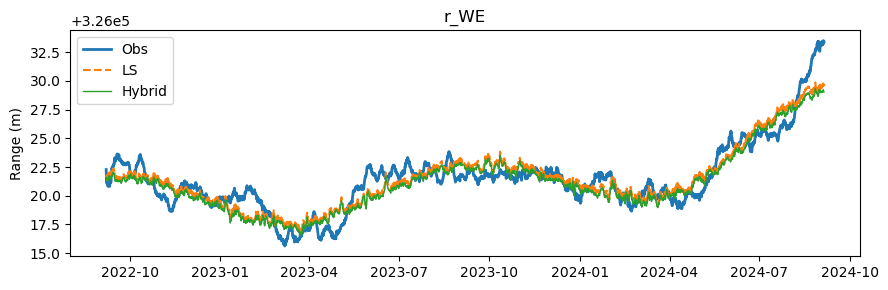

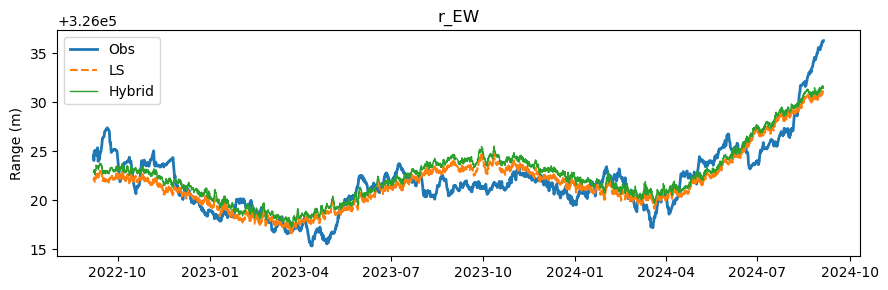

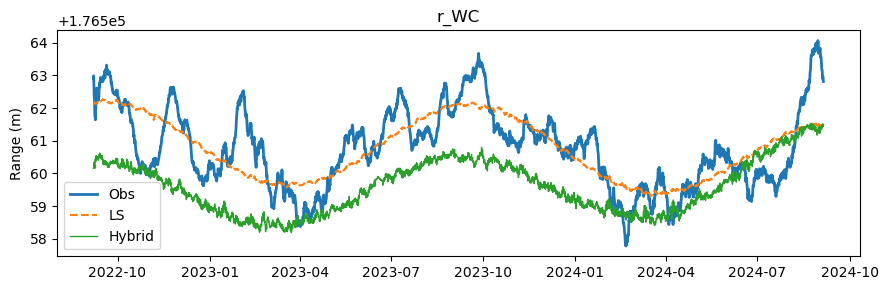

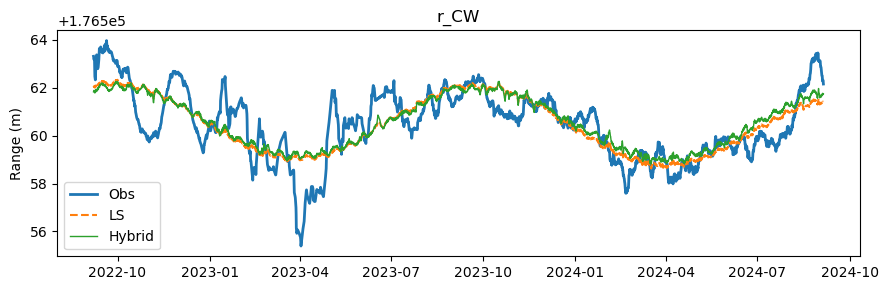

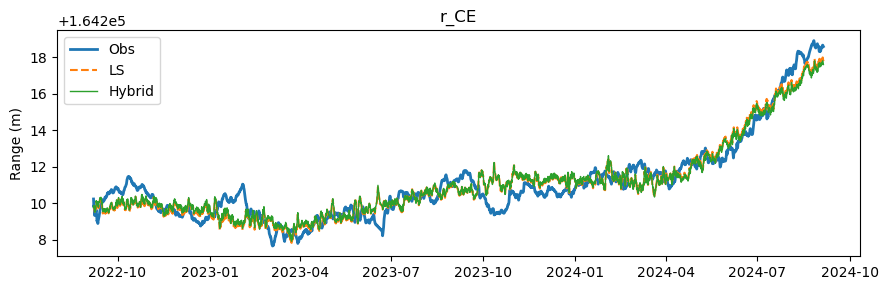

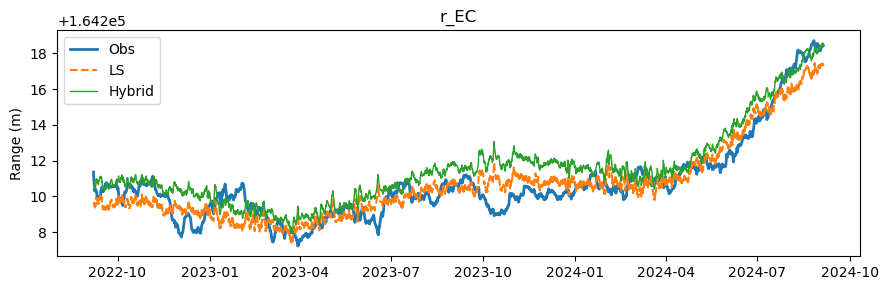

In [14]:
# ------------------------------------------------------------------ #
# 6) QUICK VISUAL CHECK (optional)
# ------------------------------------------------------------------ #
for i,name in enumerate(Y_cols):
    plt.figure(figsize=(9,3))
    plt.plot(df['time'], Y[:,i], label='Obs', lw=2)
    plt.plot(df['time'], R_lin_full[:,i], '--', label='LS')
    plt.plot(df['time'], Yh_pred[:,i], label='Hybrid', lw=1)
    plt.title(name)
    plt.ylabel("Range (m)"); plt.legend(); plt.tight_layout()
    plt.show()



In [15]:
#!/usr/bin/env python
"""
Residual-only PINN for Axial-Seamount ranging
– Baseline = linear least-squares model (fixed)
– Network learns only the residual
– Train on middle 60 %, predict full series
"""

import os, pathlib, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

# ------------------------------------------------------------------ #
# 0) CPU parallelism
# ------------------------------------------------------------------ #
os.environ.update(
    OMP_NUM_THREADS="48",
    MKL_NUM_THREADS="48",
    OPENBLAS_NUM_THREADS="48",
)
tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)

# ------------------------------------------------------------------ #
# 1) LOAD & PREP DATA
# ------------------------------------------------------------------ #
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var[df_var['Record Time'] >= pd.Timestamp(2022, 9, 7, tz='UTC')]

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1'  : df_var['p1'],   # ΔP_WC
    'p2'  : df_var['p2'],   # ΔP_EC
    'p3'  : df_var['p3'],   # absolute P_C
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
    'r_CE': df_var['d4'],
    'r_EC': df_var['d3'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# time features
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2*np.pi/365.25
df['sin_t'] = np.sin(ω*df['t_days'])
df['cos_t'] = np.cos(ω*df['t_days'])

# ------------------------------------------------------------------ #
# 2) BUILD LEAST-SQUARES BASELINE
# ------------------------------------------------------------------ #
X_raw = np.column_stack([
    df['p3'], df['p1'], df['p2'],
    df['t_days'], df['sin_t'], df['cos_t']
])
X_ls  = np.column_stack([np.ones(len(X_raw)), X_raw])

Y  = df[Y_cols].values.astype('float32')
β, *_ = np.linalg.lstsq(X_ls, Y, rcond=None)      # β shape (7,6)
R_lin_full = X_ls @ β                             # baseline prediction

# ------------------------------------------------------------------ #
# 3) SCALE FEATURES
# ------------------------------------------------------------------ #
scaler = StandardScaler().fit(X_raw)
X_scaled = scaler.transform(X_raw).astype('float32')

# ------------------------------------------------------------------ #
# 4) BUILD RESIDUAL NET
# ------------------------------------------------------------------ #
inputs = layers.Input(shape=(6,), name='inputs')

# fixed LS layer (produces baseline in scaled space)
μ, σ = scaler.mean_, np.sqrt(scaler.var_)
w_raw, b_raw = β[1:], β[0]                       # (6,6) & (6,)

w_scaled = (w_raw.T * σ).T                       # β_j·σ_j
b_scaled = b_raw + μ @ w_raw                     # b0 + Σ β_j μ_j

ls_layer = layers.Dense(6, activation='linear',
                        name='ls_fixed',
                        trainable=False,
                        weights=[w_scaled.astype('float32'),
                                 b_scaled.astype('float32')])
ls_out = ls_layer(inputs)                        # (N,6)

# residual MLP
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(128, activation='relu')(x)
resid = layers.Dense(6, activation='linear', name='resid')(x)

hybrid = layers.Add(name='hybrid')([ls_out, resid])

model = Model(inputs, hybrid)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

# ------------------------------------------------------------------ #
# 5) TRAIN / VAL SPLIT  (middle 60 %)
# ------------------------------------------------------------------ #
N = len(X_scaled)
i0, i1 = int(0.20*N), int(0.80*N)
X_train, Y_train = X_scaled[i0:i1], Y[i0:i1]

es = callbacks.EarlyStopping(monitor='loss',
                             patience=20, restore_best_weights=True)

model.fit(X_train, Y_train,
          epochs=250, batch_size=256,
          callbacks=[es], verbose=1)

# ------------------------------------------------------------------ #
# 6) EVALUATE
# ------------------------------------------------------------------ #
Y_pred = model.predict(X_scaled, verbose=0)

print("LS-only metrics:")
for i,n in enumerate(Y_cols):
    print(f"{n}: R²={r2_score(Y[:,i], R_lin_full[:,i]):.3f}, "
          f"RMSE={mean_squared_error(Y[:,i], R_lin_full[:,i], squared=False):.3f} m")

print("\nResidual-PINN metrics:")
for i,n in enumerate(Y_cols):
    print(f"{n}: R²={r2_score(Y[:,i], Y_pred[:,i]):.3f}, "
          f"RMSE={mean_squared_error(Y[:,i], Y_pred[:,i], squared=False):.3f} m")



Epoch 1/250
11/11 [==============================] - 0s 2ms/step - loss: 0.8700
Epoch 2/250
11/11 [==============================] - 0s 2ms/step - loss: 0.7594
Epoch 3/250
11/11 [==============================] - 0s 2ms/step - loss: 0.6761
Epoch 4/250
11/11 [==============================] - 0s 2ms/step - loss: 0.6005
Epoch 5/250
11/11 [==============================] - 0s 2ms/step - loss: 0.5325
Epoch 6/250
11/11 [==============================] - 0s 2ms/step - loss: 0.4765
Epoch 7/250
11/11 [==============================] - 0s 2ms/step - loss: 0.4317
Epoch 8/250
11/11 [==============================] - 0s 2ms/step - loss: 0.3948
Epoch 9/250
11/11 [==============================] - 0s 2ms/step - loss: 0.3632
Epoch 10/250
11/11 [==============================] - 0s 2ms/step - loss: 0.3332
Epoch 11/250
11/11 [==============================] - 0s 2ms/step - loss: 0.3086
Epoch 12/250
11/11 [==============================] - 0s 2ms/step - loss: 0.2873
Epoch 13/250
11/11 [=================

11/11 [==============================] - 0s 1ms/step - loss: 0.0796
Epoch 103/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0781
Epoch 104/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0789
Epoch 105/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0771
Epoch 106/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0771
Epoch 107/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0765
Epoch 108/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0756
Epoch 109/250
11/11 [==============================] - 0s 2ms/step - loss: 0.0754
Epoch 110/250
11/11 [==============================] - 0s 2ms/step - loss: 0.0750
Epoch 111/250
11/11 [==============================] - 0s 2ms/step - loss: 0.0743
Epoch 112/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0754
Epoch 113/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0746
Epoch 114/250
11/11 [=========

11/11 [==============================] - 0s 1ms/step - loss: 0.0544
Epoch 203/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0537
Epoch 204/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0543
Epoch 205/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0562
Epoch 206/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0546
Epoch 207/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0551
Epoch 208/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0530
Epoch 209/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0533
Epoch 210/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0552
Epoch 211/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0548
Epoch 212/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0522
Epoch 213/250
11/11 [==============================] - 0s 1ms/step - loss: 0.0529
Epoch 214/250
11/11 [=========

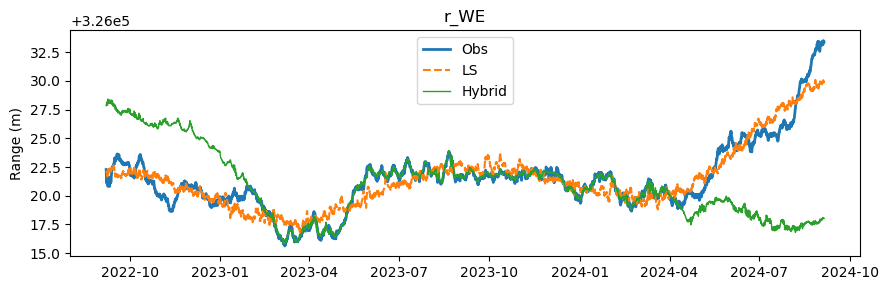

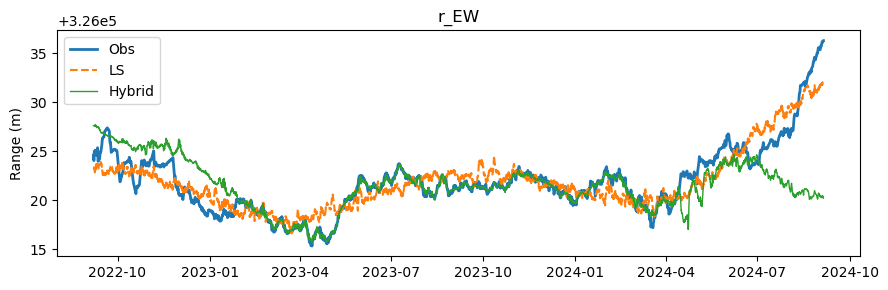

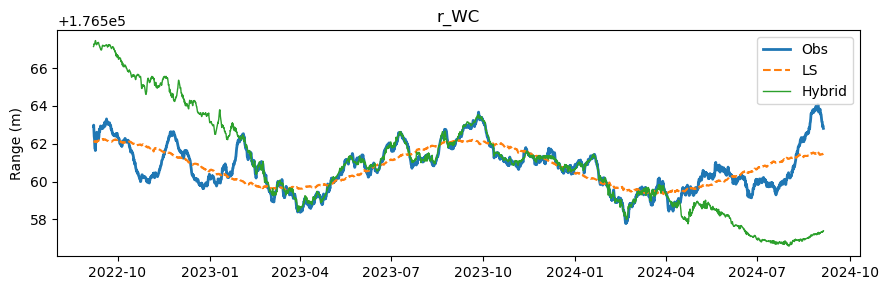

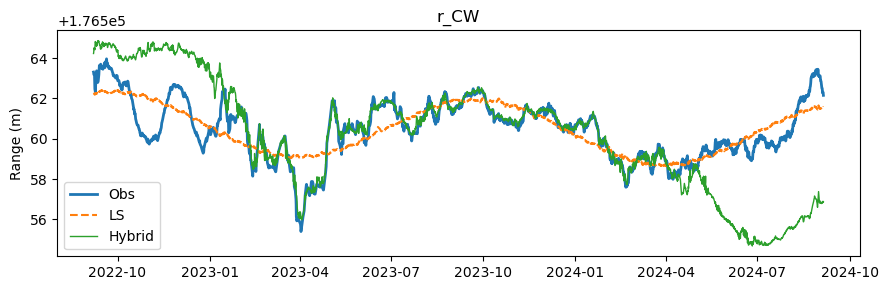

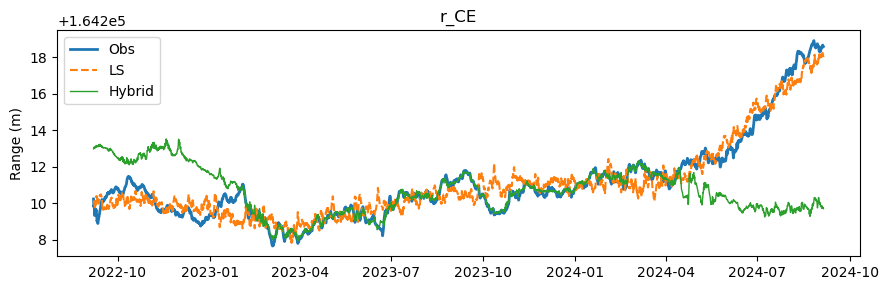

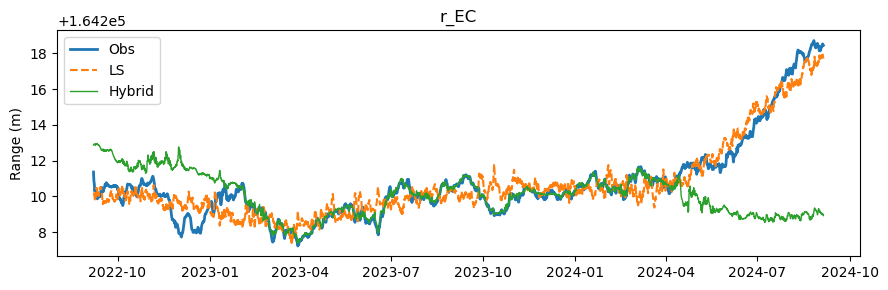

In [16]:
# ------------------------------------------------------------------ #
# 7) DIAGNOSTIC PLOTS
# ------------------------------------------------------------------ #
for i,name in enumerate(Y_cols):
    plt.figure(figsize=(9,3))
    plt.plot(df['time'], Y[:,i],      lw=2, label='Obs')
    plt.plot(df['time'], R_lin_full[:,i], '--', lw=1.5, label='LS')
    plt.plot(df['time'], Y_pred[:,i],  lw=1, label='Hybrid')
    plt.title(name); plt.ylabel('Range (m)'); plt.legend(); plt.tight_layout()
    plt.show()


In [17]:
#!/usr/bin/env python
"""
Residual-only PINN, full-series training
– LS baseline: p3, ΔP_WC, ΔP_EC, sin, cos, ramp, ramp²
– ramp starts 1 Jun 2024 (UTC)
– LS layer fixed; NN learns residual
"""

import os, pathlib, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

# ------------------------------------------------------------------ #
# 0) MULTI-CORE SET-UP
# ------------------------------------------------------------------ #
os.environ.update(
    OMP_NUM_THREADS="48",
    MKL_NUM_THREADS="48",
    OPENBLAS_NUM_THREADS="48",
)
tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)

# ------------------------------------------------------------------ #
# 1) LOAD & STRUCTURE DATA  (unchanged columns)
# ------------------------------------------------------------------ #
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var[df_var['Record Time'] >= pd.Timestamp(2022, 9, 7, tz='UTC')]

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1'  : df_var['p1'],   # ΔP_WC
    'p2'  : df_var['p2'],   # ΔP_EC
    'p3'  : df_var['p3'],   # P_C
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
    'r_CE': df_var['d4'],
    'r_EC': df_var['d3'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# ------------------------------------------------------------------ #
# 2) FEATURE ENGINEERING
# ------------------------------------------------------------------ #
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2*np.pi/365.25
df['sin_t'] = np.sin(ω*df['t_days'])
df['cos_t'] = np.cos(ω*df['t_days'])

# ramp & quadratic ramp (start 1 Jun 2024)
t_ramp0 = pd.Timestamp(2024, 6, 1, tz='UTC')
df['ramp']  = np.maximum(0.0, (df['time'] - t_ramp0).dt.total_seconds()/86400.0)
df['ramp2'] = df['ramp']**2

# ------------------------------------------------------------------ #
# 3) BUILD LINEAR LEAST-SQUARES BASELINE
# ------------------------------------------------------------------ #
X_raw = np.column_stack([
    df['p3'], df['p1'], df['p2'],
    df['sin_t'], df['cos_t'],
    df['ramp'], df['ramp2']
])
X_ls = np.column_stack([np.ones(len(X_raw)), X_raw])

Y = df[Y_cols].values.astype('float32')
β, *_ = np.linalg.lstsq(X_ls, Y, rcond=None)            # shape (8,6)
R_lin = X_ls @ β                                        # (N,6)

# ------------------------------------------------------------------ #
# 4) SCALE FEATURES
# ------------------------------------------------------------------ #
scaler = StandardScaler().fit(X_raw)
X_scaled = scaler.transform(X_raw).astype('float32')

μ, σ = scaler.mean_, np.sqrt(scaler.var_)
w_raw, b_raw = β[1:], β[0]

w_scaled = (w_raw.T * σ).T
b_scaled = b_raw + μ @ w_raw

# ------------------------------------------------------------------ #
# 5) RESIDUAL NETWORK
# ------------------------------------------------------------------ #
inputs = layers.Input(shape=(7,), name='inputs')

ls_layer = layers.Dense(
    6, activation='linear', trainable=False, name='ls_fixed',
    weights=[w_scaled.astype('float32'), b_scaled.astype('float32')]
)
ls_out = ls_layer(inputs)

x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(128, activation='relu')(x)
resid = layers.Dense(6, activation='linear')(x)

hybrid = layers.Add()([ls_out, resid])

model = Model(inputs, hybrid)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

# ------------------------------------------------------------------ #
# 6) TRAIN ON FULL SERIES  (shuffled batches)
# ------------------------------------------------------------------ #
es = callbacks.EarlyStopping(monitor='loss', patience=20,
                             restore_best_weights=True)

model.fit(X_scaled, Y,
          epochs=300, batch_size=256,
          shuffle=True, callbacks=[es], verbose=1)

# ------------------------------------------------------------------ #
# 7) EVALUATE
# ------------------------------------------------------------------ #
Y_pred = model.predict(X_scaled, verbose=0)

print("LS-only metrics:")
for i,n in enumerate(Y_cols):
    print(f"{n}: R²={r2_score(Y[:,i], R_lin[:,i]):.3f}, "
          f"RMSE={mean_squared_error(Y[:,i], R_lin[:,i], squared=False):.3f} m")

print("\nResidual-PINN metrics:")
for i,n in enumerate(Y_cols):
    print(f"{n}: R²={r2_score(Y[:,i], Y_pred[:,i]):.3f}, "
          f"RMSE={mean_squared_error(Y[:,i], Y_pred[:,i], squared=False):.3f} m")



Epoch 1/300
17/17 [==============================] - 0s 2ms/step - loss: 0.9015
Epoch 2/300
17/17 [==============================] - 0s 2ms/step - loss: 0.7923
Epoch 3/300
17/17 [==============================] - 0s 2ms/step - loss: 0.6976
Epoch 4/300
17/17 [==============================] - 0s 2ms/step - loss: 0.6154
Epoch 5/300
17/17 [==============================] - 0s 2ms/step - loss: 0.5477
Epoch 6/300
17/17 [==============================] - 0s 2ms/step - loss: 0.4998
Epoch 7/300
17/17 [==============================] - 0s 2ms/step - loss: 0.4574
Epoch 8/300
17/17 [==============================] - 0s 2ms/step - loss: 0.4240
Epoch 9/300
17/17 [==============================] - 0s 2ms/step - loss: 0.3989
Epoch 10/300
17/17 [==============================] - 0s 2ms/step - loss: 0.3759
Epoch 11/300
17/17 [==============================] - 0s 2ms/step - loss: 0.3556
Epoch 12/300
17/17 [==============================] - 0s 2ms/step - loss: 0.3392
Epoch 13/300
17/17 [=================

17/17 [==============================] - 0s 2ms/step - loss: 0.0742
Epoch 103/300
17/17 [==============================] - 0s 1ms/step - loss: 0.0729
Epoch 104/300
17/17 [==============================] - 0s 1ms/step - loss: 0.0725
Epoch 105/300
17/17 [==============================] - 0s 1ms/step - loss: 0.0731
Epoch 106/300
17/17 [==============================] - 0s 1ms/step - loss: 0.0731
Epoch 107/300
17/17 [==============================] - 0s 1ms/step - loss: 0.0732
Epoch 108/300
17/17 [==============================] - 0s 2ms/step - loss: 0.0716
Epoch 109/300
17/17 [==============================] - 0s 2ms/step - loss: 0.0711
Epoch 110/300
17/17 [==============================] - 0s 1ms/step - loss: 0.0702
Epoch 111/300
17/17 [==============================] - 0s 2ms/step - loss: 0.0698
Epoch 112/300
17/17 [==============================] - 0s 1ms/step - loss: 0.0687
Epoch 113/300
17/17 [==============================] - 0s 2ms/step - loss: 0.0692
Epoch 114/300
17/17 [=========

17/17 [==============================] - 0s 2ms/step - loss: 0.0470
Epoch 203/300
17/17 [==============================] - 0s 2ms/step - loss: 0.0470
Epoch 204/300
17/17 [==============================] - 0s 2ms/step - loss: 0.0484
Epoch 205/300
17/17 [==============================] - 0s 1ms/step - loss: 0.0478
Epoch 206/300
17/17 [==============================] - 0s 2ms/step - loss: 0.0482
Epoch 207/300
17/17 [==============================] - 0s 2ms/step - loss: 0.0496
Epoch 208/300
17/17 [==============================] - 0s 2ms/step - loss: 0.0469
Epoch 209/300
17/17 [==============================] - 0s 2ms/step - loss: 0.0462
Epoch 210/300
17/17 [==============================] - 0s 1ms/step - loss: 0.0474
Epoch 211/300
17/17 [==============================] - 0s 2ms/step - loss: 0.0468
Epoch 212/300
17/17 [==============================] - 0s 1ms/step - loss: 0.0473
Epoch 213/300
17/17 [==============================] - 0s 1ms/step - loss: 0.0467
Epoch 214/300
17/17 [=========

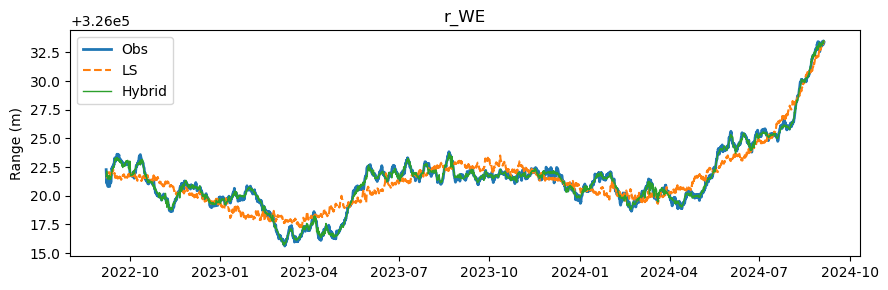

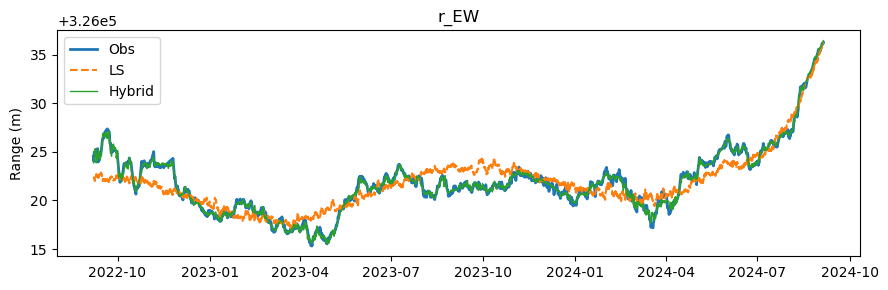

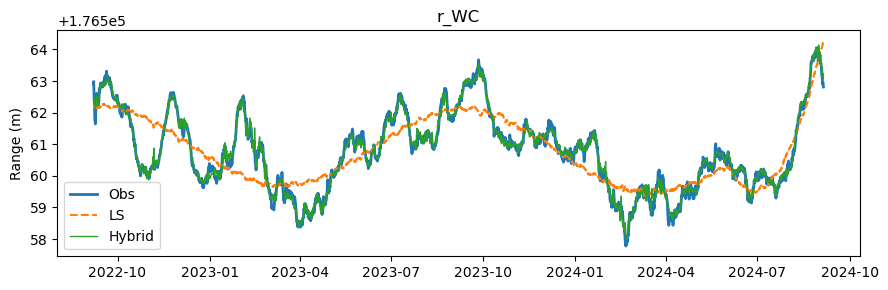

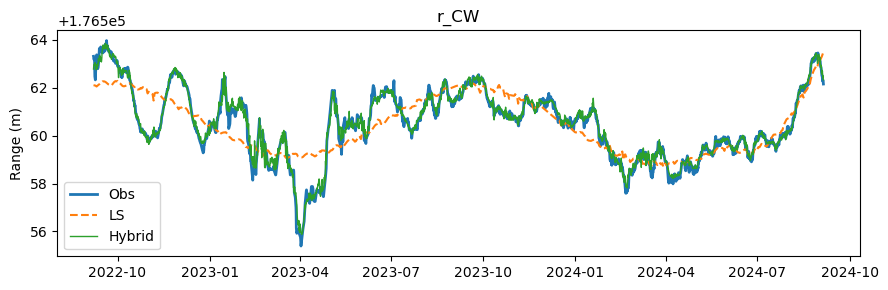

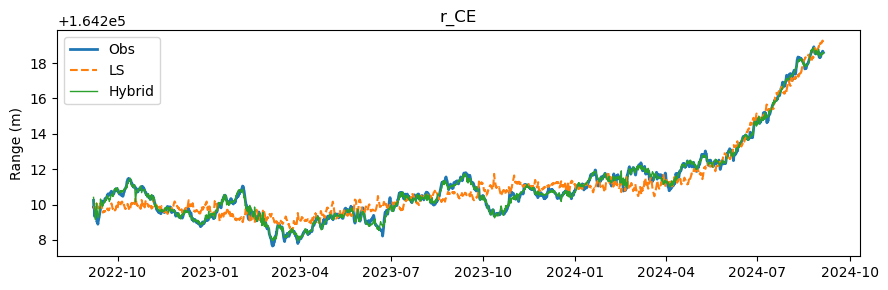

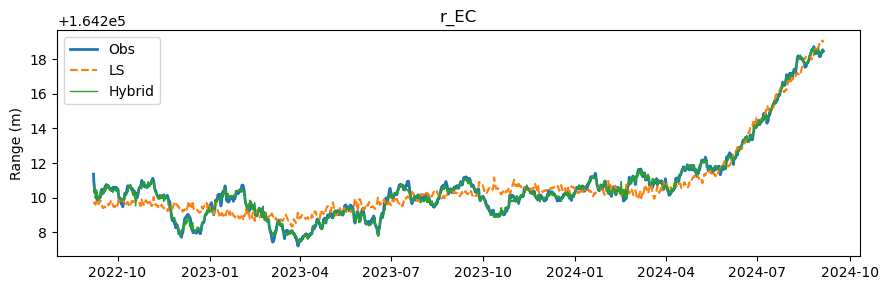

In [18]:
# ------------------------------------------------------------------ #
# 8) QUICK PLOTS (optional)
# ------------------------------------------------------------------ #
for i,name in enumerate(Y_cols):
    plt.figure(figsize=(9,3))
    plt.plot(df['time'], Y[:,i],      lw=2, label='Obs')
    plt.plot(df['time'], R_lin[:,i], '--', lw=1.5, label='LS')
    plt.plot(df['time'], Y_pred[:,i],  lw=1, label='Hybrid')
    plt.title(name); plt.ylabel('Range (m)'); plt.legend(); plt.tight_layout()
    plt.show()


In [19]:
#!/usr/bin/env python
"""
Overfitting check:
– chronological 60/20/20 split
– L2 weight decay + dropout
– early stopping on val
– evaluate on unseen 20 % tail
"""

import os, pathlib, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, regularizers

# ------------------------------------------------------------------ #
# 0) THREADING
# ------------------------------------------------------------------ #
os.environ.update(
    OMP_NUM_THREADS="48",
    MKL_NUM_THREADS="48",
    OPENBLAS_NUM_THREADS="48",
)
tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)

# ------------------------------------------------------------------ #
# 1) LOAD DATA  (same columns you use)
# ------------------------------------------------------------------ #
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var[df_var['Record Time'] >= pd.Timestamp(2022, 9, 7, tz='UTC')]

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1'  : df_var['p1'],   # ΔP_WC
    'p2'  : df_var['p2'],   # ΔP_EC
    'p3'  : df_var['p3'],   # P_C
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
    'r_CE': df_var['d4'],
    'r_EC': df_var['d3'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# ------------------------------------------------------------------ #
# 2) FEATURES (sin/cos + ramp + ramp²)
# ------------------------------------------------------------------ #
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds()/86400.0
ω = 2*np.pi/365.25
df['sin_t'] = np.sin(ω*df['t_days'])
df['cos_t'] = np.cos(ω*df['t_days'])

t_ramp0 = pd.Timestamp(2024, 6, 1, tz='UTC')
df['ramp']  = np.maximum(0, (df['time']-t_ramp0).dt.total_seconds()/86400.0)
df['ramp2'] = df['ramp']**2

X_raw = np.column_stack([
    df['p3'], df['p1'], df['p2'],
    df['sin_t'], df['cos_t'],
    df['ramp'], df['ramp2']
])
X_ls  = np.column_stack([np.ones(len(X_raw)), X_raw])

Y = df[Y_cols].values.astype('float32')
β, *_ = np.linalg.lstsq(X_ls, Y, rcond=None)
R_lin = X_ls @ β                                           # baseline

# ------------------------------------------------------------------ #
# 3) SCALE + SPLIT 60/20/20
# ------------------------------------------------------------------ #
scaler = StandardScaler().fit(X_raw)
X = scaler.transform(X_raw).astype('float32')

N       = len(X)
n_train = int(0.60*N)
n_val   = int(0.80*N)

X_train, Y_train = X[:n_train],     Y[:n_train]
X_val,   Y_val   = X[n_train:n_val],Y[n_train:n_val]
X_test,  Y_test  = X[n_val:],       Y[n_val:]
R_lin_train, R_lin_val, R_lin_test = (
    R_lin[:n_train], R_lin[n_train:n_val], R_lin[n_val:]
)

# fixed LS weights in scaled space
μ, σ = scaler.mean_, np.sqrt(scaler.var_)
w_raw, b_raw = β[1:], β[0]
w_scaled = (w_raw.T * σ).T
b_scaled = b_raw + μ @ w_raw

# ------------------------------------------------------------------ #
# 4) MODEL  (smaller + regularised)
# ------------------------------------------------------------------ #
inp = layers.Input(shape=(7,), name='inp')

ls_fixed = layers.Dense(
    6, activation='linear', trainable=False, name='ls_fixed',
    weights=[w_scaled.astype('float32'), b_scaled.astype('float32')]
)(inp)

x = layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(inp)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)
resid = layers.Dense(6, activation='linear')(x)

hybrid = layers.Add()([ls_fixed, resid])

model = Model(inp, hybrid)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

es = callbacks.EarlyStopping(monitor='val_loss', patience=20,
                             restore_best_weights=True)

hist = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=400, batch_size=256,
    callbacks=[es], verbose=1, shuffle=True
)

# ------------------------------------------------------------------ #
# 5) METRICS
# ------------------------------------------------------------------ #
def scores(y_true, y_pred, label):
    print(f"\n{label}:")
    for i,n in enumerate(Y_cols):
        print(f"{n}: R²={r2_score(y_true[:,i], y_pred[:,i]):.3f}, "
              f"RMSE={mean_squared_error(y_true[:,i], y_pred[:,i], squared=False):.3f} m")

# LS vs hybrid on each split
scores(Y_train, R_lin_train, "LS train")
scores(Y_val,   R_lin_val,   "LS val")
scores(Y_test,  R_lin_test,  "LS test")

Y_train_hat = model.predict(X_train, verbose=0)
Y_val_hat   = model.predict(X_val,   verbose=0)
Y_test_hat  = model.predict(X_test,  verbose=0)

scores(Y_train, Y_train_hat, "PINN train")
scores(Y_val,   Y_val_hat,   "PINN val")
scores(Y_test,  Y_test_hat,  "PINN test")




Epoch 1/400
11/11 [==============================] - 1s 15ms/step - loss: 1.2966 - val_loss: 0.5803
Epoch 2/400
11/11 [==============================] - 0s 4ms/step - loss: 1.2110 - val_loss: 0.5788
Epoch 3/400
11/11 [==============================] - 0s 4ms/step - loss: 1.1574 - val_loss: 0.5955
Epoch 4/400
11/11 [==============================] - 0s 4ms/step - loss: 1.1179 - val_loss: 0.6128
Epoch 5/400
11/11 [==============================] - 0s 4ms/step - loss: 1.0653 - val_loss: 0.6295
Epoch 6/400
11/11 [==============================] - 0s 4ms/step - loss: 1.0158 - val_loss: 0.6522
Epoch 7/400
11/11 [==============================] - 0s 4ms/step - loss: 0.9698 - val_loss: 0.6758
Epoch 8/400
11/11 [==============================] - 0s 4ms/step - loss: 0.9149 - val_loss: 0.7044
Epoch 9/400
11/11 [==============================] - 0s 4ms/step - loss: 0.8725 - val_loss: 0.7100
Epoch 10/400
11/11 [==============================] - 0s 4ms/step - loss: 0.8314 - val_loss: 0.7184
Epoch 11

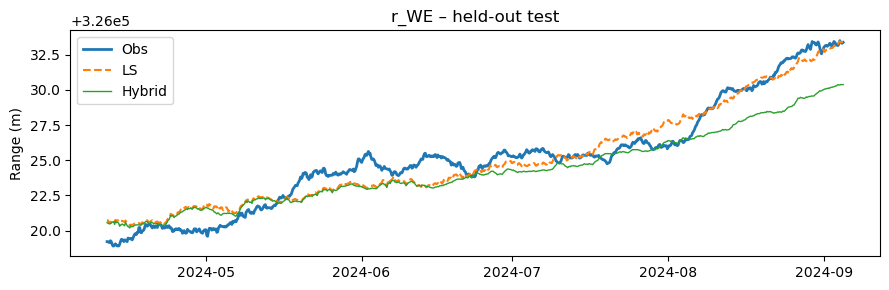

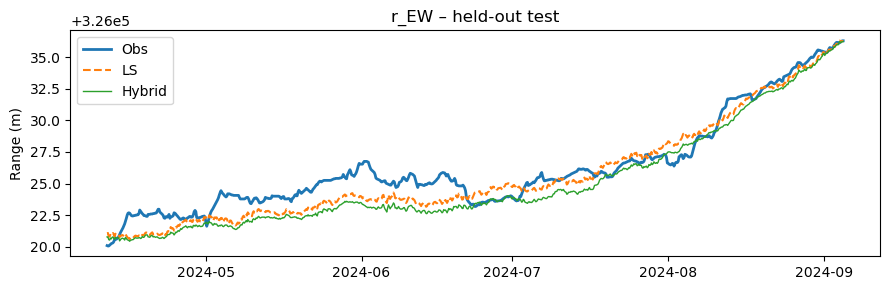

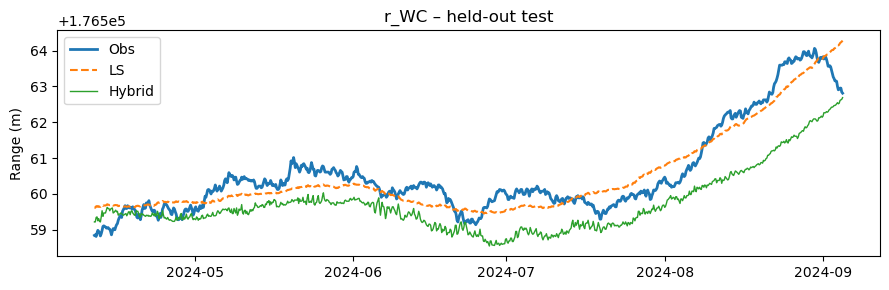

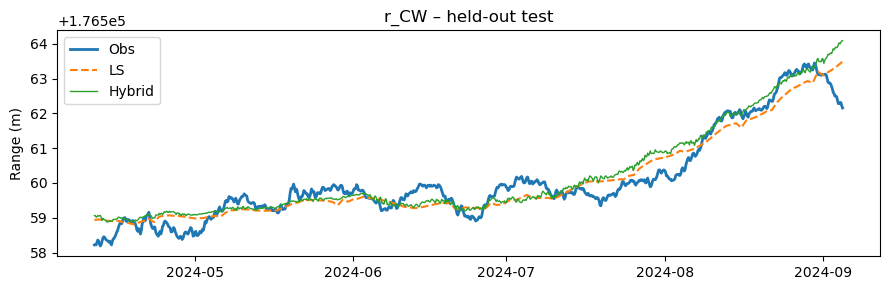

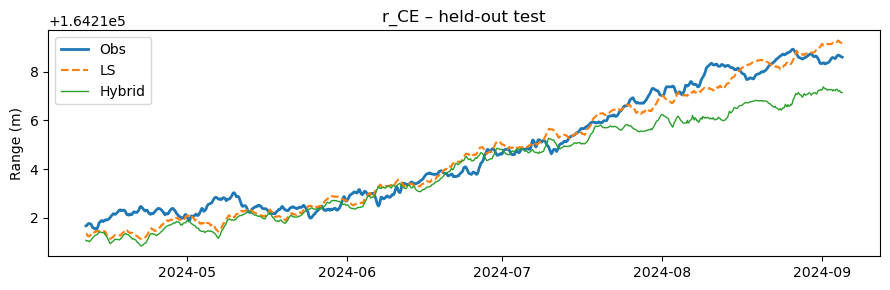

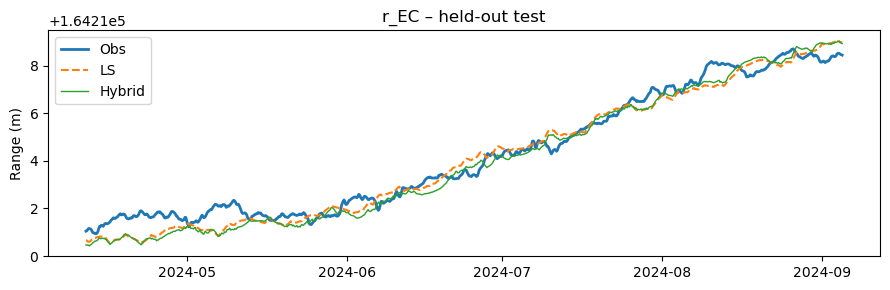

In [21]:
# ------------------------------------------------------------------ #
# 6) PLOT HELD-OUT TEST BLOCK
# ------------------------------------------------------------------ #
for i,n in enumerate(Y_cols):
    plt.figure(figsize=(9,3))
    t_test = df['time'].iloc[n_val:]
    plt.plot(t_test, Y_test[:,i],       lw=2, label='Obs')
    plt.plot(t_test, R_lin_test[:,i],  '--', lw=1.5, label='LS')
    plt.plot(t_test, Y_test_hat[:,i],    lw=1, label='Hybrid')
    plt.title(f"{n} – held-out test")
    plt.ylabel("Range (m)"); plt.legend(); plt.tight_layout()
    plt.show()

